**Cell 1: Import Libraries**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

**Cell 2: Load the Dataset**

In [27]:
df = pd.read_excel('/content/PJMW_MW_Hourly.xlsx')
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


**Cell 3: Dataset Shape & Basic Information**

In [28]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


**Cell 4: Check for Null and Duplicate Values**

In [6]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

**Cell 5: Summary Statistics & Sorting**

In [29]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


**Cell 6: Identify Missing Hourly Intervals**

In [30]:
expected_range = pd.date_range(start=df['Datetime'].min(), end=df['Datetime'].max(), freq='h')
missing_hours = expected_range.difference(df['Datetime'])
len(missing_hours)

30

**Cell 7: Outlier Detection and Correction**

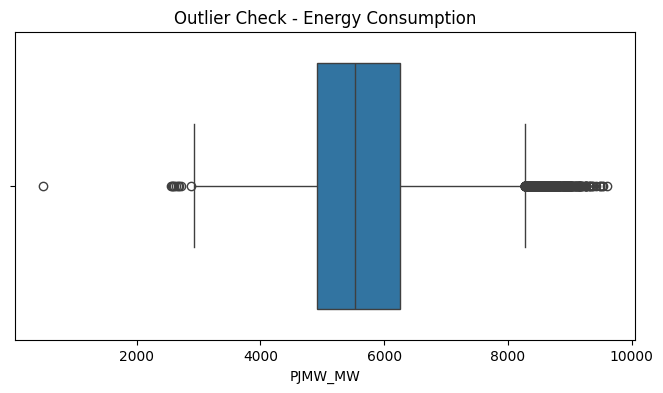

In [31]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['PJMW_MW'])
plt.title('Outlier Check - Energy Consumption')
plt.show()

# Correct the single extreme anomaly (487 MW) using linear interpolation
anomaly_index = df[df['PJMW_MW'] < 2000].index
df.loc[anomaly_index, 'PJMW_MW'] = np.nan
df['PJMW_MW'] = df['PJMW_MW'].interpolate(method='linear')

**Cell 8: Feature Extraction (Calendar & Time Components)**

In [32]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day_Name'] = df['Datetime'].dt.day_name()
df['Hour'] = df['Datetime'].dt.hour
df['Is_Weekend'] = df['Datetime'].dt.dayofweek >= 5

**Cell 9: Distribution Analysis (Histogram)**

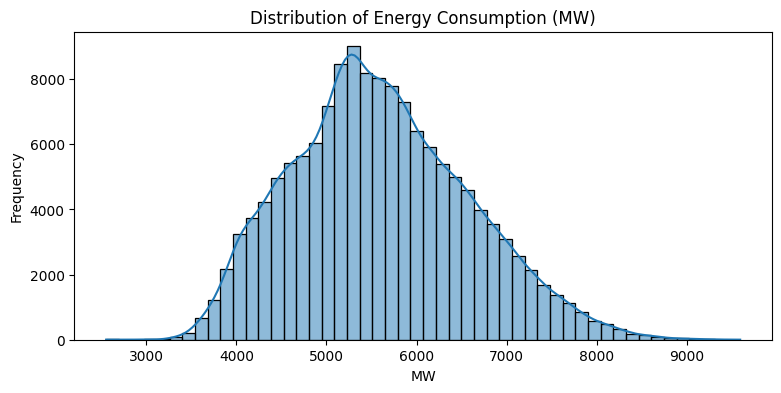

In [33]:
plt.figure(figsize=(9, 4))
sns.histplot(df['PJMW_MW'], bins=50, kde=True)
plt.title('Distribution of Energy Consumption (MW)')
plt.xlabel('MW')
plt.ylabel('Frequency')
plt.show()

**Cell 10: Complete Chronological Trend (Line Plot)**

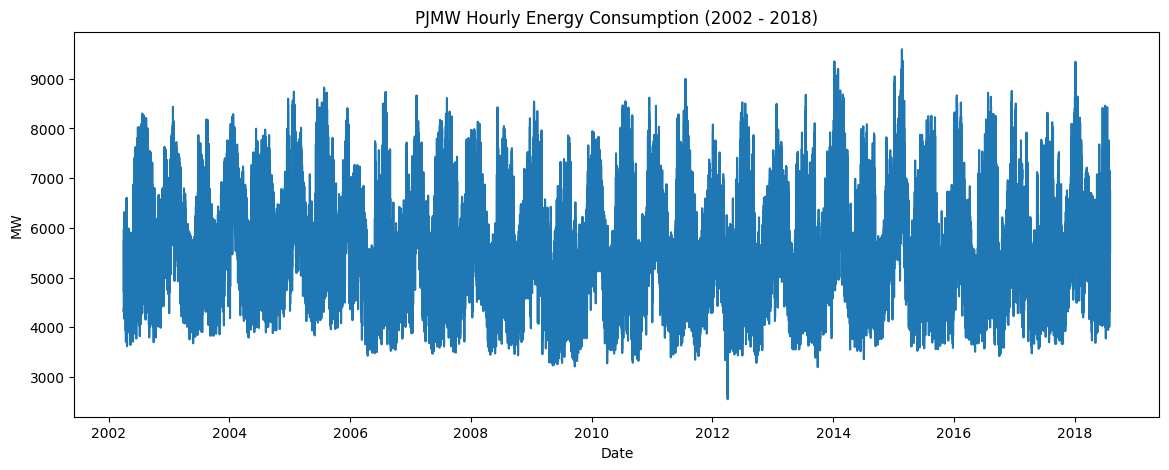

In [34]:
plt.figure(figsize=(14, 5))
plt.plot(df['Datetime'], df['PJMW_MW'])
plt.title('PJMW Hourly Energy Consumption (2002 - 2018)')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()

**Cell 11: Average Consumption by Hour of the Day**

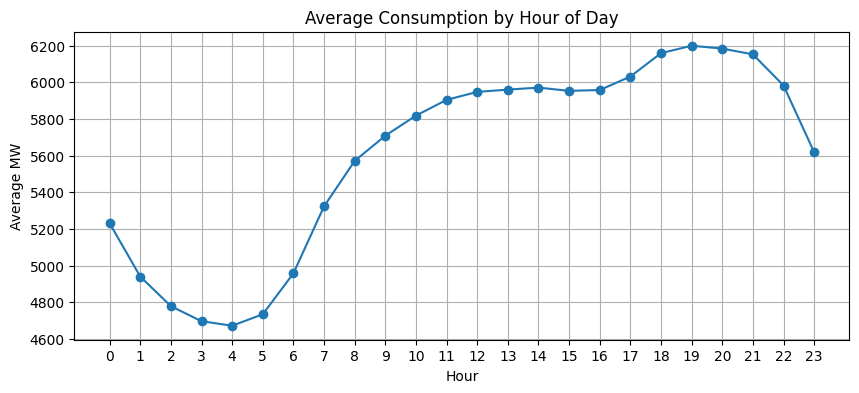

In [35]:
hourly_avg = df.groupby('Hour')['PJMW_MW'].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Consumption by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average MW')
plt.xticks(range(24))
plt.grid(True)
plt.show()

**Cell 12: Day of Week & Weekend Comparison**

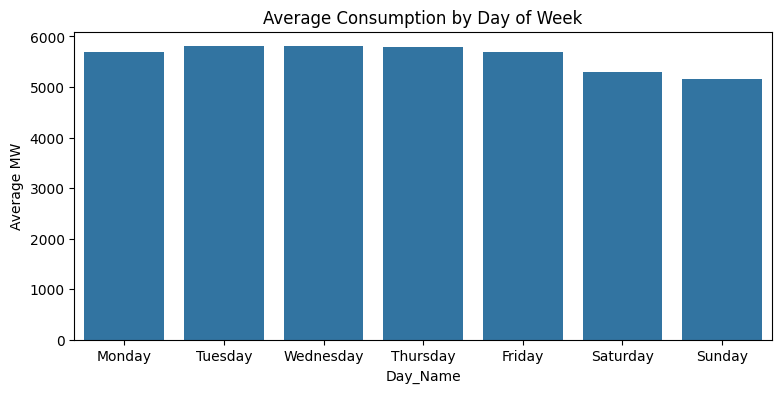

In [36]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('Day_Name')['PJMW_MW'].mean().reindex(day_order)

plt.figure(figsize=(9, 4))
sns.barplot(x=daily_avg.index, y=daily_avg.values)
plt.title('Average Consumption by Day of Week')
plt.ylabel('Average MW')
plt.show()

**Cell 13: Monthly / Seasonal Consumption Trend**

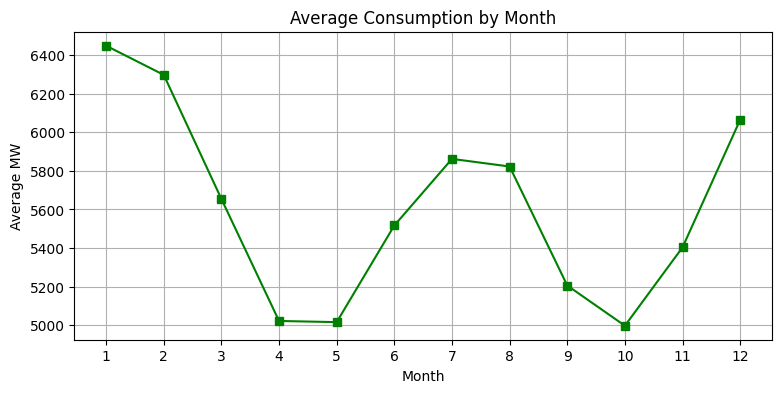

In [37]:
monthly_avg = df.groupby('Month')['PJMW_MW'].mean()

plt.figure(figsize=(9, 4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='s', color='green')
plt.title('Average Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Average MW')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

**Cell 14: Holiday vs. Non-Holiday Trend Analysis**

/tmp/ipykernel_434/2811595768.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['Is_Holiday'] = df['Datetime'].dt.date.astype('datetime64[ns]').isin(us_holidays)


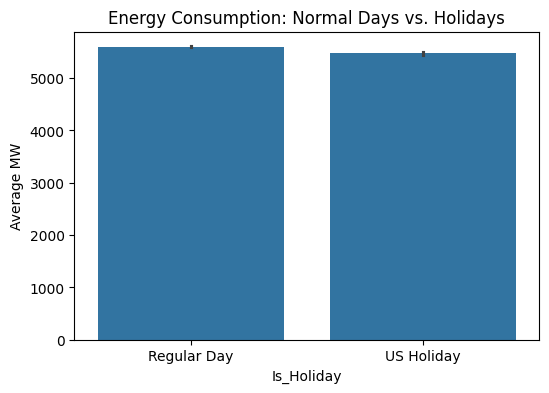

In [38]:
import holidays

# US federal holidays for the PJM region
us_holidays = holidays.US(years=range(df['Year'].min(), df['Year'].max() + 1))
df['Is_Holiday'] = df['Datetime'].dt.date.astype('datetime64[ns]').isin(us_holidays)

plt.figure(figsize=(6, 4))
sns.barplot(x='Is_Holiday', y='PJMW_MW', data=df)
plt.title('Energy Consumption: Normal Days vs. Holidays')
plt.xticks([0, 1], ['Regular Day', 'US Holiday'])
plt.ylabel('Average MW')
plt.show()

**Cell 15: Summer vs. Winter Daily/Hourly Trend Comparison**

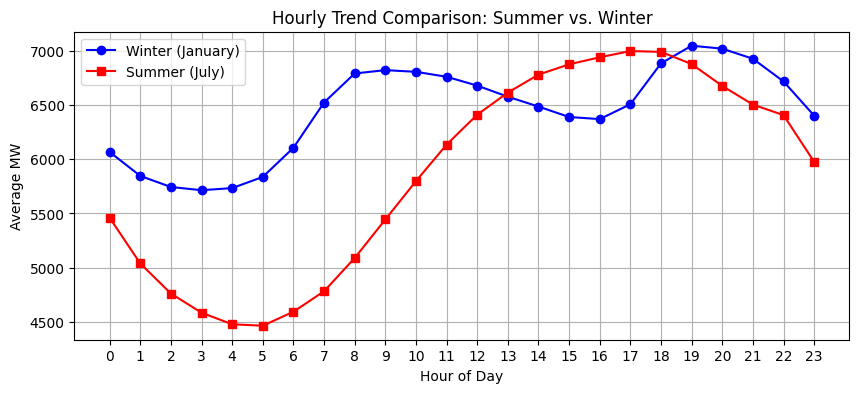

In [39]:
# Filter peak Summer (July) vs peak Winter (January)
winter_df = df[df['Month'] == 1].groupby('Hour')['PJMW_MW'].mean()
summer_df = df[df['Month'] == 7].groupby('Hour')['PJMW_MW'].mean()

plt.figure(figsize=(10, 4))
plt.plot(winter_df.index, winter_df.values, marker='o', label='Winter (January)', color='blue')
plt.plot(summer_df.index, summer_df.values, marker='s', label='Summer (July)', color='red')
plt.title('Hourly Trend Comparison: Summer vs. Winter')
plt.xlabel('Hour of Day')
plt.ylabel('Average MW')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

**Deep Learning Data Preparation (Scaling & Sequence Windowing for LSTM)**

In [40]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['PJMW_MW']])
train_data = scaled_data[:-8760]
test_data = scaled_data[-8760-500:]
def create_sequences(dataset, look_back=48):
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

look_back = 48
X_train, y_train = create_sequences(train_data, look_back)
X_test, y_test = create_sequences(test_data, look_back)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("Training Data Shape (X_train):", X_train.shape)
print("Training Labels Shape (y_train):", y_train.shape)

Training Data Shape (X_train): (134398, 48, 1)
Training Labels Shape (y_train): (134398,)


**Build LSTM/RNN Architecture**

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("--- GPU Hardware Check ---")
print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
if not gpus:
    print("WARNING: No GPU detected! Please enable T4 GPU under Runtime -> Change runtime type.")
else:
    print("GPU is active and ready for training acceleration!")

print("\n--- Building LSTM/RNN Architecture ---")
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

print("\n--- Training Model ---")
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Save the trained model locally in Colab workspace
model.save('energy_lstm_model.h5')
print("\nLSTM Model successfully trained and saved as 'energy_lstm_model.h5' in your Colab files!")

--- GPU Hardware Check ---
TensorFlow Version: 2.20.0
GPU Available: []

--- Building LSTM/RNN Architecture ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 48, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Model ---
Epoch 1/5
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 131s 67ms/step - loss: 0.0026 - val_loss: 3.7995e-04
Epoch 2/5
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 127s 67ms/step - loss: 6.1766e-04 - val_loss: 2.1526e-04
Epoch 3/5
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 126s 67ms/step - loss: 4.8004e-04 - val_loss: 2.1849e-04
Epoch 4/5
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 140s 66ms/step - loss: 4.3865e-04 - val_loss: 2.1102e-04
Epoch 5/5
1890/1890 ━━━━━━━━━━━━━━━━━━━━ 127s 67ms/step - loss: 4.1311e-04 - val_loss: 1.9065e-04



LSTM Model successfully trained and saved as 'energy_lstm_model.h5' in your Colab files!
